In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import numpy as np
import pandas as pd
import awkward as ak
import tensorflow as tf
from tensorflow import keras

import matplotlib
#matplotlib.use("Agg")
matplotlib.rcParams["figure.figsize"] = [6.4 / 1.3, 4.8 / 1.3]
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from argparse import ArgumentParser
import mplhep as hep
import vector
import hist
from hist import Hist

from general import custom_objects, feat, table_to_numpy_visualization, load_normalization, SwitchLayer, HDF5File, MaxPassLayer, TitledModel
from model_bcls import make_model as make_model_b
from model_bcls import load_data as load_data_b
from model_tt import make_model, load_data as load_data_tt

import uproot
import ROOT

Welcome to JupyROOT 6.28/04


In [2]:
particle_labels = {
    "bot": r"Bottom quark",
    "abot": r"Bottom antiquark",
    "lep": r"Lepton",
    "alep": r"Antilepton",
    "top": r"Top quark",
    "atop": r"Top antiquark",
    "ttbar": r"$\mathrm{t}\bar{\mathrm{t}}$",
    "wminus": r"$\mathrm{W}^{-}$ boson",
    "wplus": r"$\mathrm{W}^{+}$ boson",
    "met": "MET",
    "jet": "Jet"
}

obs_labels = {
    "pt": r"$p_{\mathrm{T}}$",
    "eta": r"$\eta$",
    "phi": r"$\varphi$",
    "x": r"$p_{x}$",
    "y": r"$p_{y}$",
    "z": r"$p_{z}$",
    "t": r"Energy",
    "mtt": r"$m_{\mathrm{t}\bar{\mathrm{t}}}$",
    "chel": r"$c_{\mathrm{hel}}$",
    "pttt": r"$p_{\mathrm{T},\mathrm{t}\bar{\mathrm{t}}}$",
}

obs_units = {
    "x": "GeV",
    "y": "GeV",
    "z": "GeV",
    "t": "GeV",
    "pt": "GeV",
    "mass": "GeV",
    "mtt": "GeV",
    "pttt": "GeV",
}


def get_label(observable):
    label = ""
    if "_" in observable:
        part, observable = observable.split("_")
        label += particle_labels.get(part, part) + " "
    label += obs_labels.get(observable, observable)
    if observable in obs_units:
        label += f" ({obs_units[observable]})"
    return label

def load_data(path, inputs, targets, norm):
    with HDF5File(path, "r") as f:
        data = f["data"]
        offset = f["offset"]
        scale = f["scale"]
    
    train_offset = ak.with_name(norm[0], "Dataframe")
    train_scale  = ak.with_name(norm[1], "Dataframe")
    
    # Flatten betch fields
    betch_fields = feat("betchtop", coord = "cart") + feat("betchatop", coord = "cart")
    for field in betch_fields:
        data[field] = ak.flatten(data[field])
    
    # Handling non convergence in sonnen
    sonnen_fields = feat("sonnentop", coord = "cart") + feat("sonnenatop", coord = "cart")
    sonnen_mask = (ak.num(data["sonnentop_t"]) != 1) | (ak.num(data["sonnenatop_t"]) != 1)
    
    for field in sonnen_fields:      
        # Use the mask to fill non-matching entries with None
        data[field] = ak.where(sonnen_mask, np.nan, data[field])
        # Flatten the field
        data[field] = ak.flatten(data[field], axis=None)
    
    # Add the fields to the targets
    targets = targets + betch_fields + sonnen_fields + ["dark_pt", "dark_phi"]
    
    data["weight"] = data["weight"] * scale["weight"] + offset["weight"]
    weight = np.asarray(data["weight"])
    weight = abs(weight)
    
    data_x = []
    for input in inputs:
        data_input = ak.with_name(data[input], "Dataframe")
        data_input = (data_input * scale[input] + offset[input] - train_offset[input]) / train_scale[input]
        data_x.append(table_to_numpy_visualization(data_input, input))
    
    data_y = table_to_numpy_visualization(data, targets)
    truth = data_y * table_to_numpy_visualization(scale, targets) + table_to_numpy_visualization(offset, targets)
    truth = pd.DataFrame(truth, columns=targets)
    return data_x, truth, weight


def make_lorentzvec(prefix, truth):
    vec = {}
    for p in ["x", "y", "z", "t"]:
        name = f"{prefix}_{p}"
        if p == "t":
            p = "E"
        vec[p] = np.asarray(truth[name])
    return vector.obj(**vec)

def make_2dvec(prefix, truth, coordinates='spherical'):
    vec = {}
    if coordinates=='spherical':
        for p in ["pt", "phi"]:
            name = f"{prefix}_{p}"
            vec[p] = np.asarray(truth[name]) 
        return vector.obj(rho=vec["pt"], phi=vec["phi"])
    elif coordinates=='cartesian':
        for p in ["x", "y"]:
            name = f"{prefix}_{p}"
            vec[p] = np.asarray(truth[name]) 
        return vector.obj(x=vec["x"], y=vec["y"])
    return np.nan

def switch_charge_label(label):
    if label.startswith("alep_"):
        return "lep_" + label[len("alep_"):]
    elif label.startswith("lep_"):
        return "alep_" + label[len("lep_"):]
    elif label.startswith("abot_"):
        return "bot_" + label[len("abot_"):]
    elif label.startswith("bot_"):
        return "abot_" + label[len("bot_"):]
    elif label.startswith("wminus_"):
        return "wplus_" + label[len("wminus_"):]
    elif label.startswith("wplus_"):
        return "wminus_" + label[len("wplus_"):]
    elif label.startswith("atop_"):
        return "top_" + label[len("atop_"):]
    elif label.startswith("top_"):
        return "atop_" + label[len("top_"):]
    else:
        return label


def find_switch(model):
    for layer in model.layers:
        if hasattr(layer, "layers"):
            try:
                return find_switch(layer)
            except ValueError:
                pass
        elif isinstance(layer, SwitchLayer):
            return layer
    else:
        raise ValueError("No switch in model")


def create_particle(prediction, model, index, norm, switch=False, mass=None):
    part = {}
    for i, title in enumerate(model.output_titles[index]):
        print(i, title)
        p = title.split("_")[-1]
        if switch:
            idx = model.output_titles[index].index(switch_charge_label(title))
        else:
            idx = model.output_titles[index].index(title)
        if p == "t":
            p = "E"
        try:
            part[p] = prediction[index][:, idx] * norm[1][title] + norm[0][title]
        except:
            part[p] = prediction[:, idx] * norm[1][title] + norm[0][title]
    if mass is not None:
        part["mass"] = mass
    part = vector.obj(**part)
    return part



def get_partidx(model, particle):
    titles = model.output_titles
    return [title[0].split("_")[0] for title in titles].index(particle)


In [5]:
def merge_bins(hist_ttbarSM, hist_ttZ, bin_edges, min_entries):
    merged_values_ttbarSM = []
    merged_values_ttZ = []
    merged_edges = [bin_edges[-1]]
    
    current_bin_sum_ttbarSM = 0
    current_bin_sum_ttZ = 0
    
    for i in reversed(range(len(hist_ttbarSM))):
        current_bin_sum_ttbarSM += hist_ttbarSM[i]
        current_bin_sum_ttZ += hist_ttZ[i]
        if current_bin_sum_ttbarSM + current_bin_sum_ttZ >= min_entries:
            merged_values_ttbarSM.append(current_bin_sum_ttbarSM)
            merged_values_ttZ.append(current_bin_sum_ttZ)
            merged_edges.insert(0, bin_edges[i])
            current_bin_sum_ttbarSM = 0
            current_bin_sum_ttZ = 0
    
    # If there's a remainder in the last bins, merge it into the first merged bin
    if current_bin_sum_ttbarSM > 0 or current_bin_sum_ttZ > 0:
        if merged_values_ttbarSM:
            merged_values_ttbarSM[-1] += current_bin_sum_ttbarSM
            merged_values_ttZ[-1] += current_bin_sum_ttZ
        else:
            merged_values_ttbarSM.append(current_bin_sum_ttbarSM)
            merged_values_ttZ.append(current_bin_sum_ttZ)
            merged_edges.insert(0, bin_edges[0])

    return np.array(merged_values_ttbarSM[::-1]), np.array(merged_values_ttZ[::-1]), np.array(merged_edges)


## Main

### NN method

In [6]:
BATCH_SIZE              = 2**14
RIGHT_LIMIT             = 2000
RIGHT_XLIM              = 800
BINS_DENSITY            = 80
NN_LAYERS_BEFORE_CONCAT = 2
NN_LAYERS_AFTER_CONCAT  = 2
NN_NODES_PER_LAYER      = 200
NN_ACTIVATION_FUNCTION  = "relu"
NN_DROPOUT_RATE         = 0.25
NN_LEARNING_RATE        = 0.0003
NN_LEARNING_RATE_DECAY  = 0
VALIDATE_MASS           = 100
DM_FRAC                 = 50
N_ENTRIES               = 10

# Paths to data and models
TRAIN_DATA_PATH    = f"/nfs/dust/cms/user/coradine/DATA_SPECIAL_DM_SM_100/DM_{DM_FRAC}_SM_{100-DM_FRAC}/traindata.hdf5"
VALIDATE_DATA_PATH = f"/nfs/dust/cms/user/stafford/For_Emanuele/reconn/1308_nn_lim_ins/_TTbarDMJets_Dilepton_scalar_LO_Mchi_1_Mphi_{VALIDATE_MASS}_TuneCP5_13TeV_madgraph_mcatnlo_pythia8/validatedata.hdf5"
MODEL_B_PATH       = f"/nfs/dust/cms/user/coradine/Top-Pair-Reco-NN/dark_pt_DM_{DM_FRAC}_SM_{100-DM_FRAC}/model_bcls.hdf5"
MODEL_TT_PATH      = f"/nfs/dust/cms/user/coradine/Top-Pair-Reco-NN/dark_pt_DM_{DM_FRAC}_SM_{100-DM_FRAC}/model_tt.hdf5"

SM_DATA_PATH  = "/nfs/dust/cms/user/stafford/For_Emanuele/reconn/2008_lighter_ttbar/TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8/validatedata.hdf5"
TTZ_DATA_PATH = "/nfs/dust/cms/user/stafford/For_Emanuele/reconn/1308_nn_lim_ins/TTZToLLNuNu_M-10_TuneCP5_13TeV-amcatnlo-pythia8/validatedata.hdf5"
OUTPUT_PATH   = ""

In [ ]:
with HDF5File(TRAIN_DATA_PATH, "r") as f:
    data = f["data"]
    offset = f["offset"]
    scale = f["scale"]


In [8]:
# Load normalization data
norm = load_normalization(TRAIN_DATA_PATH)

# Load training and validation data
features1     = feat("jet") + ["jet_btag"]
features2     = feat("alep") + feat("lep") + ["met_pt", "met_phi", "met_x", "met_y"]
train_data    = load_data_b(TRAIN_DATA_PATH, features1, features2)
validate_data = load_data_b(VALIDATE_DATA_PATH, features1, features2)

# Reconstruct the model_b
model_b = make_model_b(
    [t.shape for t in train_data[0]],  # Input shapes
    [features1, features2],            # Input titles
    [NN_LAYERS_BEFORE_CONCAT, 0],      # Number of layers per input
    NN_LAYERS_AFTER_CONCAT,            # Number of layers after concatenation
    NN_NODES_PER_LAYER,                # Number of nodes per layer
    NN_ACTIVATION_FUNCTION,            # Activation function
    NN_DROPOUT_RATE,                   # Dropout rate
    train_data[1].shape[1],            # Number of outputs
    [],                                # Output titles
    NN_LEARNING_RATE,                  # Learning rate
    NN_LEARNING_RATE_DECAY             # Learning rate decay
)

model_b.load_weights(MODEL_B_PATH)

# Add the MaxPassLayer and continue growing the tt model
b_out = MaxPassLayer(2)([model_b.output, model_b.inputs[0]])
model_bbar = TitledModel(
    model_b.input_titles,
    [p + t.split("_")[1] for t in model_b.input_titles[0] for p in ("bot_", "abot_")],
    inputs=model_b.inputs, outputs=[b_out]
)
model_bbar.trainable = False

inputs = model_b.input_titles + [["met_pt", "met_phi", "met_x", "met_y", "MT2ll"] + feat("lep") + feat("alep")]
targets = [
    ["gendmmed_x", "gendmmed_y"]
]

train_data_tt = load_data_tt(TRAIN_DATA_PATH, inputs, targets)
validate_data_tt = load_data_tt(VALIDATE_DATA_PATH, inputs, targets)
model = make_model(
    [t.shape for t in train_data_tt[0]],  # Input shapes
    inputs,                               # Input titles
    [model_bbar],                         # Additional models
    [0, 2],                               # Number of layers per input
    4,                                    # Number of layers after concatenation
    1000,                                  # Number of nodes per layer
    "relu",                               # Activation function
    0.25,                                 # Dropout rate
    targets,                              # Number of outputs
    0.001,                                # Learning rate
    0                                     # Learning rate decay
)
norm = load_normalization(TRAIN_DATA_PATH)

model.load_weights(MODEL_TT_PATH)

# Load common data
targets_common = feat("top") + feat("atop") +\
                 feat("genlep") + feat("genalep") +\
                 feat("genbot") + feat("genabot") + feat("ttbar") +\
                 feat("lep") + feat("alep") +\
                 feat("bot") + feat("abot") + ["mtt", "chel", "MT2ll"] + ["met_pt", "met_phi"] 


# Load target DM files
targets_DM = feat("top") + feat("atop") +\
                 feat("genlep") + feat("genalep") +\
                 feat("genbot") + feat("genabot") + feat("ttbar") +\
                 feat("gendmmed", coord="cart") +\
                 feat("lep") + feat("alep") +\
                 feat("bot") + feat("abot") + ["mtt", "chel", "MT2ll"] + ["met_pt", "met_phi"]

data_x, truth, weight = load_data(VALIDATE_DATA_PATH, model.input_titles, targets_DM, norm)

# Generated quantities
top      = make_lorentzvec("top", truth)
atop     = make_lorentzvec("atop", truth)
genlep   = make_lorentzvec("genlep", truth)
genalep  = make_lorentzvec("genalep", truth)
genbot   = make_lorentzvec("genbot", truth)
genabot  = make_lorentzvec("genabot", truth)
gendmmed = make_lorentzvec("gendmmed", truth)

# Reconstructed by algorithms
lep  = make_lorentzvec("lep", truth)
alep = make_lorentzvec("alep", truth)
bot  = make_lorentzvec("bot", truth)
abot = make_lorentzvec("abot", truth)
MET  = make_2dvec("met", truth)

betchtop  = make_lorentzvec("betchtop", truth)
betchatop = make_lorentzvec("betchatop", truth)
dm_betch  = make_2dvec("dark", truth)
MT2ll = truth["MT2ll"]

# Load SM file
targets_ttbarSM = targets_common

data_x_ttbarSM, truth_ttbarSM, weight_ttbarSM = load_data(SM_DATA_PATH, model.input_titles, targets_ttbarSM, norm)

# Generated quantities for SM
top_ttbarSM     = make_lorentzvec("top", truth_ttbarSM)
atop_ttbarSM    = make_lorentzvec("atop", truth_ttbarSM)
genlep_ttbarSM  = make_lorentzvec("genlep", truth_ttbarSM)
genalep_ttbarSM = make_lorentzvec("genalep", truth_ttbarSM)
genbot_ttbarSM  = make_lorentzvec("genbot", truth_ttbarSM)
genabot_ttbarSM = make_lorentzvec("genabot", truth_ttbarSM)

# Reconstructed by algorithms for SM
lep_ttbarSM  = make_lorentzvec("lep", truth_ttbarSM)
alep_ttbarSM = make_lorentzvec("alep", truth_ttbarSM)
bot_ttbarSM  = make_lorentzvec("bot", truth_ttbarSM)
abot_ttbarSM = make_lorentzvec("abot", truth_ttbarSM)
MET_ttbarSM  = make_2dvec("met", truth_ttbarSM)

betchtop_ttbarSM  = make_lorentzvec("betchtop", truth_ttbarSM)
betchatop_ttbarSM = make_lorentzvec("betchatop", truth_ttbarSM)
dm_betch_ttbarSM  = make_2dvec("dark", truth_ttbarSM)
MT2ll_ttbarSM = truth_ttbarSM["MT2ll"]


# Load ttZ file
targets_ttZ = targets_common

data_x_ttZ, truth_ttZ, weight_ttZ = load_data(TTZ_DATA_PATH, model.input_titles, targets_ttZ, norm)

# Generated quantities for ttZ
top_ttZ     = make_lorentzvec("top", truth_ttZ)
atop_ttZ    = make_lorentzvec("atop", truth_ttZ)
genlep_ttZ  = make_lorentzvec("genlep", truth_ttZ)
genalep_ttZ = make_lorentzvec("genalep", truth_ttZ)
genbot_ttZ  = make_lorentzvec("genbot", truth_ttZ)
genabot_ttZ = make_lorentzvec("genabot", truth_ttZ)

# Reconstructed by algorithms for ttZ
lep_ttZ  = make_lorentzvec("lep", truth_ttZ)
alep_ttZ = make_lorentzvec("alep", truth_ttZ)
bot_ttZ  = make_lorentzvec("bot", truth_ttZ)
abot_ttZ = make_lorentzvec("abot", truth_ttZ)
MET_ttZ  = make_2dvec("met", truth_ttZ)

betchtop_ttZ  = make_lorentzvec("betchtop", truth_ttZ)
betchatop_ttZ = make_lorentzvec("betchatop", truth_ttZ)
dm_betch_ttZ  = make_2dvec("dark", truth_ttZ)
MT2ll_ttZ = truth_ttZ["MT2ll"]

In [16]:
model.summary()

Model: "titled_model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 21)]         0           []                               
                                                                                                  
 dense_4 (Dense)                (None, 1000)         22000       ['input_5[0][0]']                
                                                                                                  
 dropout_4 (Dropout)            (None, 1000)         0           ['dense_4[0][0]']                
                                                                                                  
 input_3 (InputLayer)           [(None, 7, 9)]       0           []                               
                                                                                     

In [9]:
prediction = model.predict(data_x, batch_size=BATCH_SIZE)

2/2 [==============================] - 3s 252ms/step


In [12]:
darkpt_pred = create_particle(prediction, model, get_partidx(model, "gendmmed"), norm)
darkpt_pred

0 gendmmed_x
1 gendmmed_y


vector.obj(x=[ -7.6053524  22.203495  -21.43798   ...  36.248215    5.6904125
 -11.912848 ], y=[ -7.5897646  41.748966  -51.773922  ...  11.011253  -25.11554
 -10.984963 ])

In [13]:
# Use NN to reconstruct top quarks
# os.makedirs(output, exist_ok=True)

prediction = model.predict(data_x, batch_size=BATCH_SIZE)
#top_pred   = create_particle(prediction, model, get_partidx(model, "top"), norm)
#atop_pred  = create_particle(prediction, model, get_partidx(model, "atop"), norm)
#ttbar_pred = top_pred + atop_pred
darkpt_pred = create_particle(prediction, model, get_partidx(model, "gendmmed"), norm)

# Use NN to reconstruct top quarks in SM dataset
prediction_ttbarSM = model.predict(data_x_ttbarSM, batch_size=BATCH_SIZE)
#top_pred_ttbarSM   = create_particle(prediction_ttbarSM, model, get_partidx(model, "top"), norm)
#atop_pred_ttbarSM  = create_particle(prediction_ttbarSM, model, get_partidx(model, "atop"), norm)
#ttbar_pred_ttbarSM = top_pred_ttbarSM + atop_pred_ttbarSM
darkpt_pred_ttbarSM = create_particle(prediction_ttbarSM, model, get_partidx(model, "gendmmed"), norm)

# Use NN to reconstruct top quarks in ttZ dataset
prediction_ttZ = model.predict(data_x_ttZ, batch_size=BATCH_SIZE)
#top_pred_ttZ   = create_particle(prediction_ttZ, model, get_partidx(model, "top"), norm)
#atop_pred_ttZ  = create_particle(prediction_ttZ, model, get_partidx(model, "atop"), norm)
#ttbar_pred_ttZ = top_pred_ttZ + atop_pred_ttZ
darkpt_pred_ttZ = create_particle(prediction_ttZ, model, get_partidx(model, "gendmmed"), norm)

# Reconstruct DM with NN
#neutrinos_pred     = top_pred + atop_pred - lep - alep - bot - abot
#neutrinos_MET_pred = vector.obj(rho=neutrinos_pred.pt, phi=neutrinos_pred.phi)
#dm_MET_pred        = (MET - neutrinos_MET_pred).rho
dm_MET_pred = darkpt_pred.rho

# Reconstruct DM with NN in SM case
#neutrinos_pred_ttbarSM     = top_pred_ttbarSM + atop_pred_ttbarSM - lep_ttbarSM - alep_ttbarSM - bot_ttbarSM - abot_ttbarSM
#neutrinos_MET_pred_ttbarSM = vector.obj(rho=neutrinos_pred_ttbarSM.pt, phi=neutrinos_pred_ttbarSM.phi)
#dm_MET_pred_ttbarSM        = (MET_ttbarSM - neutrinos_MET_pred_ttbarSM).rho
dm_MET_pred_ttbarSM = darkpt_pred_ttbarSM.rho

# Reconstruct DM with NN in ttZ case
#neutrinos_pred_ttZ     = top_pred_ttZ + atop_pred_ttZ - lep_ttZ - alep_ttZ - bot_ttZ - abot_ttZ
#neutrinos_MET_pred_ttZ = vector.obj(rho=neutrinos_pred_ttZ.pt, phi=neutrinos_pred_ttZ.phi)
#dm_MET_pred_ttZ        = (MET_ttZ - neutrinos_MET_pred_ttZ).rho
dm_MET_pred_ttZ = darkpt_pred_ttZ.rho

# Reconstruct DM with Betch
dm_pt_betch         = dm_betch.rho
dm_pt_betch_ttbarSM = dm_betch_ttbarSM.rho
dm_pt_betch_ttZ     = dm_betch_ttZ.rho

2/2 [==============================] - 1s 250ms/step
0 gendmmed_x
1 gendmmed_y
26/26 [==============================] - 9s 359ms/step
0 gendmmed_x
1 gendmmed_y
3/3 [==============================] - 1s 208ms/step
0 gendmmed_x
1 gendmmed_y


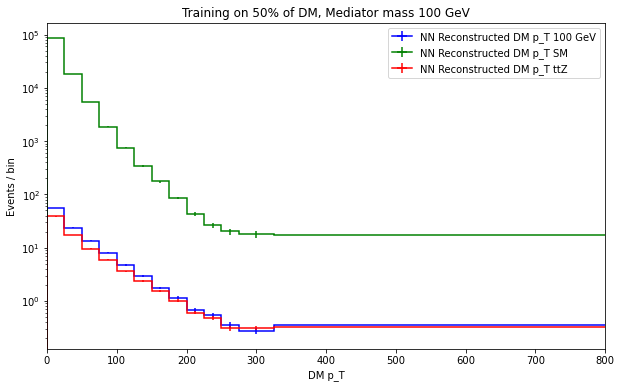

In [14]:
# Calculate initial weighted histograms for ttbarSM and ttZ
h_ttbarSM = Hist(hist.axis.Regular(BINS_DENSITY, 0, RIGHT_LIMIT, label="NN Reconstructed DM p_T SM"), storage=hist.storage.Weight())
h_ttZ     = Hist(hist.axis.Regular(BINS_DENSITY, 0, RIGHT_LIMIT, label="NN Reconstructed DM p_T ttZ"), storage=hist.storage.Weight())

h_ttbarSM.fill(dm_MET_pred_ttbarSM[dm_MET_pred_ttbarSM < RIGHT_LIMIT], weight=weight_ttbarSM[dm_MET_pred_ttbarSM < RIGHT_LIMIT])
h_ttZ.fill(dm_MET_pred_ttZ[dm_MET_pred_ttZ < RIGHT_LIMIT], weight=weight_ttZ[dm_MET_pred_ttZ < RIGHT_LIMIT])

# Merge bins based on the combined sum of ttbarSM and ttZ histograms
merged_ttbarSM, merged_ttZ, merged_edges = merge_bins(h_ttbarSM.values(), h_ttZ.values(), h_ttbarSM.axes.edges[0], N_ENTRIES)

# Create new histograms with merged binning for all histograms
h_MET_pred = Hist(hist.axis.Variable(merged_edges, label="NN Reconstructed DM p_T"), storage=hist.storage.Weight())
h_MET_pred_ttbarSM = Hist(hist.axis.Variable(merged_edges, label="NN Reconstructed DM p_T SM"), storage=hist.storage.Weight())
h_MET_pred_ttZ = Hist(hist.axis.Variable(merged_edges, label="NN Reconstructed DM p_T ttZ"), storage=hist.storage.Weight())

# Fill the histograms with the new binning and weights
h_MET_pred.fill(dm_MET_pred[dm_MET_pred < RIGHT_LIMIT], weight=weight[dm_MET_pred < RIGHT_LIMIT])
h_MET_pred_ttbarSM.fill(dm_MET_pred_ttbarSM[dm_MET_pred_ttbarSM < RIGHT_LIMIT], weight=weight_ttbarSM[dm_MET_pred_ttbarSM < RIGHT_LIMIT])
h_MET_pred_ttZ.fill(dm_MET_pred_ttZ[dm_MET_pred_ttZ < RIGHT_LIMIT], weight=weight_ttZ[dm_MET_pred_ttZ < RIGHT_LIMIT])


h_betch_ttbarSM = Hist(hist.axis.Regular(BINS_DENSITY, 0, RIGHT_LIMIT, label="Betchart Reconstructed DM p_T SM"), storage=hist.storage.Weight())
h_betch_ttZ = Hist(hist.axis.Regular(BINS_DENSITY, 0, RIGHT_LIMIT, label="Betchart Reconstructed DM p_T ttZ"), storage=hist.storage.Weight())

# Fill Betchart histograms
h_betch_ttbarSM.fill(dm_pt_betch_ttbarSM[dm_pt_betch_ttbarSM < RIGHT_LIMIT], weight=weight_ttbarSM[dm_pt_betch_ttbarSM < RIGHT_LIMIT])
h_betch_ttZ.fill(dm_pt_betch_ttZ[dm_pt_betch_ttZ < RIGHT_LIMIT], weight=weight_ttZ[dm_pt_betch_ttZ < RIGHT_LIMIT])

# Merge bins for Betchart histograms
merged_betch_ttbarSM, merged_betch_ttZ, merged_betch_edges = merge_bins(h_betch_ttbarSM.values(), h_betch_ttZ.values(), h_betch_ttbarSM.axes.edges[0], N_ENTRIES)

# Create new Betchart histograms with merged binning
h_betch = Hist(hist.axis.Variable(merged_betch_edges, label="Betchart Reconstructed DM p_T"), storage=hist.storage.Weight())
h_betch_ttbarSM_merged = Hist(hist.axis.Variable(merged_betch_edges, label="Betchart Reconstructed DM p_T SM"), storage=hist.storage.Weight())
h_betch_ttZ_merged = Hist(hist.axis.Variable(merged_betch_edges, label="Betchart Reconstructed DM p_T ttZ"), storage=hist.storage.Weight())

# Fill the merged Betchart histograms
h_betch.fill(dm_pt_betch[dm_pt_betch < RIGHT_LIMIT], weight=weight[dm_pt_betch < RIGHT_LIMIT])
h_betch_ttbarSM_merged.fill(dm_pt_betch_ttbarSM[dm_pt_betch_ttbarSM < RIGHT_LIMIT], weight=weight_ttbarSM[dm_pt_betch_ttbarSM < RIGHT_LIMIT])
h_betch_ttZ_merged.fill(dm_pt_betch_ttZ[dm_pt_betch_ttZ < RIGHT_LIMIT], weight=weight_ttZ[dm_pt_betch_ttZ < RIGHT_LIMIT])


# Plot the merged histograms on the same canvas
plt.figure(figsize=(10, 6))
h_MET_pred.plot1d(label=f"NN Reconstructed DM p_T {VALIDATE_MASS} GeV", color="blue", histtype='step')
h_MET_pred_ttbarSM.plot1d(label="NN Reconstructed DM p_T SM", color="green", histtype='step')
h_MET_pred_ttZ.plot1d(label="NN Reconstructed DM p_T ttZ", color="red", histtype='step')

plt.xlabel("DM p_T")
plt.xlim(0, RIGHT_XLIM)
plt.ylabel("Events / bin")
plt.title(f"Training on {DM_FRAC}% of DM, Mediator mass {VALIDATE_MASS} GeV")
plt.legend()
plt.yscale('log')
plt.show()

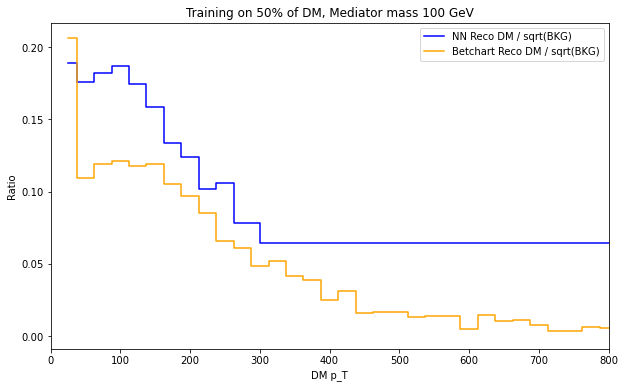

In [15]:
# Calculate and plot the ratio of NN Reconstructed DM and Betchart DM to the combined background
combined_background_MET = h_MET_pred_ttbarSM.values() + h_MET_pred_ttZ.values()
combined_background_betch = h_betch_ttbarSM_merged.values() + h_betch_ttZ_merged.values()

ratio_MET = np.divide(
    h_MET_pred.values(),
    np.sqrt(combined_background_MET),
    out=np.zeros_like(h_MET_pred.values(), dtype=float),
    where=combined_background_MET != 0
)

ratio_betch = np.divide(
    h_betch.values(),
    np.sqrt(combined_background_betch),
    out=np.zeros_like(h_betch.values(), dtype=float),
    where=combined_background_betch != 0
)

# Plot the ratios with xlim
#bin_centers_MET = 0.5 * (merged_edges[1:] + merged_edges[:-1])
#bin_centers_betch = 0.5 * (merged_betch_edges[1:] + merged_betch_edges[:-1])
bin_centers_MET = merged_edges[1:]
bin_centers_betch = merged_betch_edges[1:] 


plt.figure(figsize=(10, 6))
plt.plot(bin_centers_MET, ratio_MET, drawstyle='steps-mid', label="NN Reco DM / sqrt(BKG)", color="blue")
plt.plot(bin_centers_betch, ratio_betch, drawstyle='steps-mid', label="Betchart Reco DM / sqrt(BKG)", color="orange")

plt.xlabel("DM p_T")
plt.ylabel("Ratio")
plt.xlim(0, RIGHT_XLIM)
plt.title(f"Training on {DM_FRAC}% of DM, Mediator mass {VALIDATE_MASS} GeV")
plt.legend()
plt.show()

In [16]:
# File name and directory name
root_file_name = "combine_dataset.root"
directory_name = "signal_region"

# Define the names for the TH1F histograms
hist_names = {
    "h_MET_pred": f"ttDM_{VALIDATE_MASS}",
    "h_MET_pred_ttbarSM": "ttbar",
    "h_MET_pred_ttZ": "ttZ"
}

# Convert the histograms to NumPy format
histograms_to_write = {
    hist_names["h_MET_pred"]: h_MET_pred.to_numpy(),
    hist_names["h_MET_pred_ttbarSM"]: h_MET_pred_ttbarSM.to_numpy(),
    hist_names["h_MET_pred_ttZ"]: h_MET_pred_ttZ.to_numpy()
}

# Open the ROOT file in "UPDATE" mode (to overwrite or add to existing file)
root_file = ROOT.TFile(root_file_name, "UPDATE")

# Create or access the TDirectory
if not root_file.GetDirectory(directory_name):
    root_dir = root_file.mkdir(directory_name)
else:
    root_dir = root_file.GetDirectory(directory_name)
root_dir.cd()

# Convert and write the histograms
for name, (values, edges) in histograms_to_write.items():
    # Create ROOT TH1F histogram
    n_bins = len(values)
    root_hist = ROOT.TH1F(name, name, n_bins, edges)
    
    # Fill the ROOT histogram with values
    for i in range(n_bins):
        root_hist.SetBinContent(i + 1, values[i])
    
    # Write the histogram to the ROOT file
    root_hist.Write("", ROOT.TObject.kOverwrite)

# Close the ROOT file
root_file.Close()

### MT2ll method with dark pt

In [1]:
CUT          = 110
NENTRIES_CUT = 10

In [ ]:
plt.hist(MT2ll, 80)
plt.show()

In [ ]:
plt.hist(MT2ll_ttbarSM, 80)
plt.show()

In [ ]:
plt.hist(MT2ll_ttZ, 80)
plt.show()

In [ ]:
mask_MT2ll = (MT2ll > CUT)
mask_MT2ll_ttbarSM = (MT2ll_ttbarSM > CUT)
mask_MT2ll_ttZ = (MT2ll_ttZ > CUT)

dm_pt_betch_CUT         = dm_pt_betch[mask_MT2ll]
dm_pt_betch_ttbarSM_CUT = dm_pt_betch_ttbarSM[mask_MT2ll_ttbarSM]
dm_pt_betch_ttZ_CUT     = dm_pt_betch_ttZ[mask_MT2ll_ttZ]

weight_CUT         = weight[mask_MT2ll]
weight_ttbarSM_CUT = weight_ttbarSM[mask_MT2ll_ttbarSM]
weight_ttZ_CUT     = weight_ttZ[mask_MT2ll_ttZ]

In [ ]:
plt.hist(dm_pt_betch_CUT, 100, density = False)
plt.show()
plt.hist(dm_pt_betch_ttbarSM_CUT, 100)
plt.show()
plt.hist(dm_pt_betch_ttZ_CUT, 100)
plt.show()

In [ ]:
h_betch_ttbarSM_CUT = Hist(hist.axis.Regular(BINS_DENSITY, 0, RIGHT_LIMIT, label=f"Betchart Reconstructed DM p_T SM MT2ll > {CUT}"), storage=hist.storage.Weight())
h_betch_ttZ_CUT = Hist(hist.axis.Regular(BINS_DENSITY, 0, RIGHT_LIMIT, label=f"Betchart Reconstructed DM p_T ttZ MT2ll > {CUT}"), storage=hist.storage.Weight())

# Fill Betchart histograms
h_betch_ttbarSM_CUT.fill(dm_pt_betch_ttbarSM_CUT[dm_pt_betch_ttbarSM_CUT < RIGHT_LIMIT], weight=weight_ttbarSM_CUT[dm_pt_betch_ttbarSM_CUT < RIGHT_LIMIT])
h_betch_ttZ_CUT.fill(dm_pt_betch_ttZ_CUT[dm_pt_betch_ttZ_CUT < RIGHT_LIMIT], weight=weight_ttZ_CUT[dm_pt_betch_ttZ_CUT < RIGHT_LIMIT])

# Merge bins for Betchart histograms
merged_betch_ttbarSM_CUT, merged_betch_ttZ_CUT, merged_betch_edges_CUT = merge_bins(h_betch_ttbarSM_CUT.values(), h_betch_ttZ_CUT.values(), h_betch_ttbarSM_CUT.axes.edges[0], NENTRIES_CUT)

# Create new Betchart histograms with merged binning
h_betch_CUT                = Hist(hist.axis.Variable(merged_betch_edges_CUT, label=f"Betchart Reconstructed DM p_T MT2ll > {CUT}"), storage=hist.storage.Weight())
h_betch_ttbarSM_merged_CUT = Hist(hist.axis.Variable(merged_betch_edges_CUT, label=f"Betchart Reconstructed DM p_T SM MT2ll > {CUT}"), storage=hist.storage.Weight())
h_betch_ttZ_merged_CUT     = Hist(hist.axis.Variable(merged_betch_edges_CUT, label=f"Betchart Reconstructed DM p_T ttZ MT2ll > {CUT}"), storage=hist.storage.Weight())

# Fill the merged Betchart histograms
h_betch_CUT.fill(dm_pt_betch_CUT[dm_pt_betch_CUT < RIGHT_LIMIT], weight=weight_CUT[dm_pt_betch_CUT < RIGHT_LIMIT])
h_betch_ttbarSM_merged_CUT.fill(dm_pt_betch_ttbarSM_CUT[dm_pt_betch_ttbarSM_CUT < RIGHT_LIMIT], weight=weight_ttbarSM_CUT[dm_pt_betch_ttbarSM_CUT < RIGHT_LIMIT])
h_betch_ttZ_merged_CUT.fill(dm_pt_betch_ttZ_CUT[dm_pt_betch_ttZ_CUT < RIGHT_LIMIT], weight=weight_ttZ_CUT[dm_pt_betch_ttZ_CUT < RIGHT_LIMIT])


# Plot the merged histograms on the same canvas
plt.figure(figsize=(10, 6))
h_betch_CUT.plot1d(label=f"Betchart Reconstructed DM p_T {VALIDATE_MASS} GeV MT2ll > {CUT}", color="blue", histtype='step')
h_betch_ttbarSM_merged_CUT.plot1d(label=f"Betchart Reconstructed DM p_T SM MT2ll > {CUT}", color="green", histtype='step')
h_betch_ttZ_merged_CUT.plot1d(label=f"Betchart Reconstructed DM p_T ttZ MT2ll > {CUT}", color="red", histtype='step')

plt.xlabel("DM p_T")
plt.xlim(0, RIGHT_XLIM)
plt.ylabel("Events / bin")
plt.title(f"Merged Histograms with Minimum Entries per Bin = {N_ENTRIES}")
plt.legend()

plt.show()

In [ ]:
# File name and directory name
root_file_name = "combine_dataset.root"
directory_name = "signal_region"

# Define the names for the TH1F histograms
hist_names = {
    "h_betch_CUT": f"DarkPT_MT2ll_ttDM_{VALIDATE_MASS}",
    "h_betch_ttbarSM_merged_CUT": "DarkPT_MT2ll_ttbar",
    "h_betch_ttZ_merged_CUT": "DarkPT_MT2ll_ttZ"
}

# Convert the histograms to NumPy format
histograms_to_write = {
    hist_names["h_betch_CUT"]: h_betch_CUT.to_numpy(),
    hist_names["h_betch_ttbarSM_merged_CUT"]: h_betch_ttbarSM_merged_CUT.to_numpy(),
    hist_names["h_betch_ttZ_merged_CUT"]: h_betch_ttZ_merged_CUT.to_numpy()
}

# Open the ROOT file in "UPDATE" mode (to overwrite or add to existing file)
root_file = ROOT.TFile(root_file_name, "UPDATE")

# Create or access the TDirectory
if not root_file.GetDirectory(directory_name):
    root_dir = root_file.mkdir(directory_name)
else:
    root_dir = root_file.GetDirectory(directory_name)
root_dir.cd()

# Convert and write the histograms
for name, (values, edges) in histograms_to_write.items():
    # Create ROOT TH1F histogram
    n_bins = len(values)
    root_hist = ROOT.TH1F(name, name, n_bins, edges)
    
    # Fill the ROOT histogram with values
    for i in range(n_bins):
        root_hist.SetBinContent(i + 1, values[i])
    
    # Write the histogram to the ROOT file
    root_hist.Write("", ROOT.TObject.kOverwrite)

# Close the ROOT file
root_file.Close()

### MT2ll method with MET

In [ ]:
CUT          = 110
NENTRIES_CUT = 10

In [ ]:
mask_MT2ll = (MT2ll > CUT)
mask_MT2ll_ttbarSM = (MT2ll_ttbarSM > CUT)
mask_MT2ll_ttZ = (MT2ll_ttZ > CUT)

MET_CUT         = MET.rho[mask_MT2ll]
MET_ttbarSM_CUT = MET_ttbarSM.rho[mask_MT2ll_ttbarSM]
MET_ttZ_CUT     = MET_ttZ.rho[mask_MT2ll_ttZ]

weight_CUT         = weight[mask_MT2ll]
weight_ttbarSM_CUT = weight_ttbarSM[mask_MT2ll_ttbarSM]
weight_ttZ_CUT     = weight_ttZ[mask_MT2ll_ttZ]

In [ ]:
plt.hist(MET_CUT, 100, density = False)
plt.show()
plt.hist(MET_ttbarSM_CUT, 100)
plt.show()
plt.hist(MET_ttZ_CUT, 100)
plt.show()

In [ ]:
h_MET_ttbarSM_CUT = Hist(hist.axis.Regular(BINS_DENSITY, 0, RIGHT_LIMIT, label=f"MET SM MT2ll > {CUT}"), storage=hist.storage.Weight())
h_MET_ttZ_CUT = Hist(hist.axis.Regular(BINS_DENSITY, 0, RIGHT_LIMIT, label=f"MET ttZ MT2ll > {CUT}"), storage=hist.storage.Weight())

# Fill Betchart histograms
h_MET_ttbarSM_CUT.fill(MET_ttbarSM_CUT[MET_ttbarSM_CUT < RIGHT_LIMIT], weight=weight_ttbarSM_CUT[MET_ttbarSM_CUT < RIGHT_LIMIT])
h_MET_ttZ_CUT.fill(MET_ttZ_CUT[MET_ttZ_CUT < RIGHT_LIMIT], weight=weight_ttZ_CUT[MET_ttZ_CUT < RIGHT_LIMIT])

# Merge bins for Betchart histograms
merged_MET_ttbarSM_CUT, merged_MET_ttZ_CUT, merged_MET_edges_CUT = merge_bins(h_MET_ttbarSM_CUT.values(), h_MET_ttZ_CUT.values(), h_MET_ttbarSM_CUT.axes.edges[0], NENTRIES_CUT)

# Create new Betchart histograms with merged binning
h_MET_CUT                = Hist(hist.axis.Variable(merged_MET_edges_CUT, label=f"MET MT2ll > {CUT}"), storage=hist.storage.Weight())
h_MET_ttbarSM_merged_CUT = Hist(hist.axis.Variable(merged_MET_edges_CUT, label=f"MET SM MT2ll > {CUT}"), storage=hist.storage.Weight())
h_MET_ttZ_merged_CUT     = Hist(hist.axis.Variable(merged_MET_edges_CUT, label=f"MET ttZ MT2ll > {CUT}"), storage=hist.storage.Weight())

# Fill the merged Betchart histograms
h_MET_CUT.fill(MET_CUT[MET_CUT < RIGHT_LIMIT], weight=weight_CUT[MET_CUT < RIGHT_LIMIT])
h_MET_ttbarSM_merged_CUT.fill(MET_ttbarSM_CUT[MET_ttbarSM_CUT < RIGHT_LIMIT], weight=weight_ttbarSM_CUT[MET_ttbarSM_CUT < RIGHT_LIMIT])
h_MET_ttZ_merged_CUT.fill(MET_ttZ_CUT[MET_ttZ_CUT < RIGHT_LIMIT], weight=weight_ttZ_CUT[MET_ttZ_CUT < RIGHT_LIMIT])


# Plot the merged histograms on the same canvas
plt.figure(figsize=(10, 6))
h_MET_CUT.plot1d(label=f"MET {VALIDATE_MASS} GeV MT2ll > {CUT}", color="blue", histtype='step')
h_MET_ttbarSM_merged_CUT.plot1d(label=f"MET SM MT2ll > {CUT}", color="green", histtype='step')
h_MET_ttZ_merged_CUT.plot1d(label=f"MET ttZ MT2ll > {CUT}", color="red", histtype='step')

plt.xlabel("MET")
plt.xlim(0, RIGHT_XLIM)
plt.ylabel("Events / bin")
plt.title(f"Merged Histograms with Minimum Entries per Bin = {N_ENTRIES}")
plt.legend()

plt.show()

In [ ]:
# File name and directory name
root_file_name = "combine_dataset.root"
directory_name = "signal_region"

# Define the names for the TH1F histograms
hist_names = {
    "h_MET_CUT": f"MET_MT2ll_ttDM_{VALIDATE_MASS}",
    "h_MET_ttbarSM_merged_CUT": "MET_MT2ll_ttbar",
    "h_MET_ttZ_merged_CUT": "MET_MT2ll_ttZ"
}

# Convert the histograms to NumPy format
histograms_to_write = {
    hist_names["h_MET_CUT"]: h_MET_CUT.to_numpy(),
    hist_names["h_MET_ttbarSM_merged_CUT"]: h_MET_ttbarSM_merged_CUT.to_numpy(),
    hist_names["h_MET_ttZ_merged_CUT"]: h_MET_ttZ_merged_CUT.to_numpy()
}

# Open the ROOT file in "UPDATE" mode (to overwrite or add to existing file)
root_file = ROOT.TFile(root_file_name, "UPDATE")

# Create or access the TDirectory
if not root_file.GetDirectory(directory_name):
    root_dir = root_file.mkdir(directory_name)
else:
    root_dir = root_file.GetDirectory(directory_name)
root_dir.cd()

# Convert and write the histograms
for name, (values, edges) in histograms_to_write.items():
    # Create ROOT TH1F histogram
    n_bins = len(values)
    root_hist = ROOT.TH1F(name, name, n_bins, edges)
    
    # Fill the ROOT histogram with values
    for i in range(n_bins):
        root_hist.SetBinContent(i + 1, values[i])
    
    # Write the histogram to the ROOT file
    root_hist.Write("", ROOT.TObject.kOverwrite)

# Close the ROOT file
root_file.Close()